In [1]:
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import defaultdict
from scipy import stats

from turker_eval_lib import *

path = "../connectives_turkers_results_all.csv"
gold_path = "../Gold_Answers.csv"

In [2]:
df_gold = pd.read_csv(gold_path)
df_gold.head()
#remove causal
df_gold = df_gold[df_gold["stimuli-type"] != "causal"]
df_gold = df_gold.drop("Jessy", axis=1)
df_gold = df_gold.drop("Kyle", axis=1)
# df_gold.head()

In [3]:
df_gold.insert(loc=df_gold.shape[1], column="majority", value=None)
df_gold.insert(loc=df_gold.shape[1], column="%majority", value=None)
df_gold.insert(loc=df_gold.shape[1], column="consensus", value=None)
# df_gold.head()

In [4]:
#make everything floats
# df_gold = df_gold.astype({"Daniel":float, "Will":float, "Kyle":float, "Jessy":float, "Kanishka":float})
df_gold = df_gold.astype({"Daniel":float, "Will":float, "Kanishka":float})
#calculate majority + consensus
for index, row in df_gold.iterrows():
    DW_agree = (df_gold.loc[index,'Daniel'] == df_gold.loc[index,'Will'] or math.isnan(float(df_gold.loc[index,'Will'])))
    # DK1_agree = (df_gold.loc[index,'Daniel'] == df_gold.loc[index,'Kyle'] or math.isnan(float(df_gold.loc[index,'Kyle'])))
    DK2_agree = (df_gold.loc[index,'Daniel'] == df_gold.loc[index,'Kanishka'] or math.isnan(float(df_gold.loc[index,'Kanishka'])))
    # DJ_agree = (df_gold.loc[index,'Daniel'] == df_gold.loc[index,'Jessy'] or math.isnan(float(df_gold.loc[index,'Jessy'])))
    
    # responses_nans = [df_gold.loc[index,'Daniel'], df_gold.loc[index,'Will'], df_gold.loc[index,'Kyle'], df_gold.loc[index,'Kanishka'], df_gold.loc[index,'Jessy']]
    responses_nans = [df_gold.loc[index,'Daniel'], df_gold.loc[index,'Will'], df_gold.loc[index,'Kanishka']]
    responses = []
    for r in responses_nans:
        if not math.isnan(r):
            responses.append(int(r))
    
    # if DW_agree and DK1_agree and DK2_agree and DJ_agree:
    if DW_agree and DK2_agree:
        df_gold.loc[index,'consensus'] = df_gold.loc[index,'Daniel']
    else:
        df_gold.loc[index,'consensus'] = None
    
    counts = np.bincount(responses, minlength=3)
    if counts[1] > counts[2]:
        df_gold.loc[index,'majority'] = 1
        
        df_gold.loc[index,'%majority'] = (counts[1] / len(responses))
    elif counts[1] < counts[2]:
        df_gold.loc[index,'majority'] = 2
        
        df_gold.loc[index,'%majority'] = (counts[2] / len(responses))
    else:
        df_gold.loc[index,'majority'] = None
        
        df_gold.loc[index,'%majority'] = None

    
# df_gold.head()

In [5]:
# print(df_gold["consensus"].value_counts(dropna=False))
# print()
# print(df_gold["majority"].value_counts(dropna=False))
# print(df_gold["consensus"].shape)

In [6]:
print(len(df_gold[df_gold["Daniel"] == df_gold["consensus"]]))
print(len(df_gold))
print("\nDaniel")
print("Consensus:", gold_accuracy(df_gold, "Daniel"))
print("Majority:", gold_accuracy(df_gold, "Daniel", "majority"))

print("\nKanishka")
print("Consensus:", gold_accuracy(df_gold, "Kanishka"))
print("Majority:", gold_accuracy(df_gold, "Kanishka", "majority"))

print("\nWill")
print("Consensus:", gold_accuracy(df_gold, "Will"))
print("Majority:", gold_accuracy(df_gold, "Will", "majority"))

74
88

Daniel
Consensus: 0.8409090909090909
Majority: 0.9545454545454546

Kanishka
Consensus: 0.8409090909090909
Majority: 0.9772727272727273

Will
Consensus: 0.8409090909090909
Majority: 0.9090909090909091


In [7]:
df = pd.read_csv(path)
df.head(2)  
max_batches = int((len(df) / 9) + 1) # 9 is number of workers per problem, +1 is to work with range(1,max_batches)

In [8]:
# Seperate same worker doing two different batches
worker_ids = []
remaining = ["tmp"]
while not len(remaining) == 0:
    remaining = []
    worker_ids = []
    for index, row in df.iterrows():
        worker = df.loc[index, "WorkerId"]
        if not worker in worker_ids:
            worker_ids.append(worker)
        else:
            df.loc[index,"WorkerId"] = str(worker) + "_SECOND"
            worker = df.loc[index, "WorkerId"]
            worker_ids.append(worker)
            remaining.append(worker)
            print(worker)

ACHM2SO6R1SPZ_SECOND
A3O8JFBBMFKHWP_SECOND
A1H2KFCXC57JTD_SECOND
A6R6M6KVKTKZT_SECOND
AFWQB4527V3F2_SECOND
A1WKUNC2NQCX5J_SECOND
A36HN50WA7RGAZ_SECOND
A36HN50WA7RGAZ_SECOND
A3OUAR84WQO03Y_SECOND
A25IZ76G0Z0WXT_SECOND
A3QMIV19OI5589_SECOND
A3PKRJOKC5QYX6_SECOND
A3KLBK6128F8HC_SECOND
A36HN50WA7RGAZ_SECOND_SECOND


In [9]:
len(df["WorkerId"])

216

In [10]:
df_sorted = df["WorkTimeInSeconds"].sort_values().astype(float)

In [11]:
df_sorted.index
np.array(df_sorted)

array([ 77., 100., 122., 124., 127., 140., 145., 173., 179., 182., 186.,
       198., 199., 199., 201., 202., 204., 209., 212., 222., 227., 239.,
       241., 245., 245., 248., 251., 252., 257., 260., 268., 268., 271.,
       277., 278., 279., 287., 292., 296., 300., 303., 304., 304., 309.,
       319., 320., 323., 324., 324., 326., 327., 333., 336., 344., 348.,
       349., 355., 358., 363., 366., 366., 367., 368., 372., 377., 377.,
       379., 379., 380., 381., 383., 383., 383., 384., 386., 388., 391.,
       396., 399., 400., 404., 404., 404., 407., 407., 415., 423., 425.,
       430., 432., 433., 437., 442., 450., 456., 458., 459., 459., 460.,
       464., 466., 481., 481., 486., 489., 494., 494., 495., 495., 496.,
       496., 498., 499., 503., 505., 509., 510., 510., 511., 514., 515.,
       518., 519., 520., 520., 522., 526., 531., 536., 539., 539., 539.,
       540., 540., 540., 544., 547., 548., 549., 550., 555., 559., 560.,
       565., 566., 567., 573., 580., 584., 585., 58

In [12]:
y = np.array(df_sorted)
x = np.arange(0, len(y))

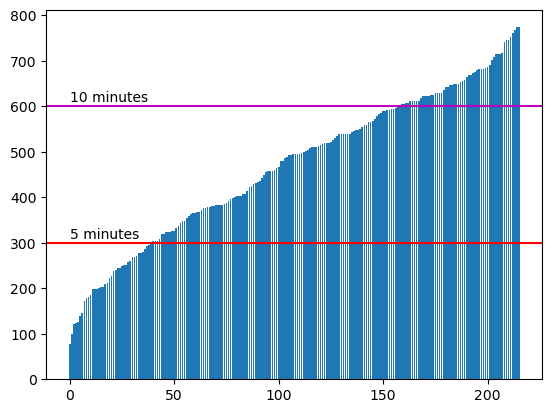

In [13]:
plt.bar(x, y)
plt.axhline(y=300,color="r") # 5 minutes
plt.text(x=0, y=310, s="5 minutes")

plt.axhline(y=600,color="m") # 10 minutes
plt.text(x=0, y=610, s="10 minutes")
plt.show()


In [14]:
print("Average time:\t\t", y.mean() / 60, "min\t\t", y.mean() , "seconds")
print("std deviation time:\t", y.std() / 60, "min\t\t", y.std() , "seconds")
print()
print("max time:\t\t", y.max() / 60, "min\t\t", y.max() , "seconds")
print("max time:\t\t", y.min() / 60, "min\t\t", y.min() , "seconds")


Average time:		 7.812731481481482 min		 468.7638888888889 seconds
std deviation time:	 2.764086387493603 min		 165.84518324961616 seconds

max time:		 12.9 min		 774.0 seconds
max time:		 1.2833333333333334 min		 77.0 seconds


In [59]:
df_sample_1 = get_batch(df, 1)
# df_sample_1

In [16]:
answers = get_answers(df_sample_1)
answers

,WorkerId,Answer.106_6_temporal_wugfest_even though_blicketbash_blicketbash occured before wugfest._before,Answer.106_6_temporal_wugfest_even though_blicketbash_wugfest occured before blicketbash._before,Answer.120_10_preference_Daxburgh_nevertheless_Gektopia_Daxburgh has skyscrapers._hate,Answer.120_10_preference_Daxburgh_nevertheless_Gektopia_Gektopia has skyscrapers._hate,Answer.125_5_temporal_daxday_hence_fepfestival_daxday occured before fepfestival._before,Answer.125_5_temporal_daxday_hence_fepfestival_fepfestival occured before daxday._before,Answer.129_9_preference_Daxburgh_since_Blicketland_Blicketland is a coastal city._hate,Answer.129_9_preference_Daxburgh_since_Blicketland_Daxburgh is a coastal city._hate,Answer.133_3_preference_daxes_so_blickets_blickets are blue flowers._love,...,Answer.77_7_preference_Daxburgh_for_Fepopolis_Daxburgh has mountains._hate,Answer.77_7_preference_Daxburgh_for_Fepopolis_Fepopolis has mountains._hate,Answer.80_10_preference_Wugsville_for_Gektopia_Gektopia has skyscrapers._love,Answer.80_10_preference_Wugsville_for_Gektopia_Wugsville has skyscrapers._love,Answer.8_8_preference_Daxburgh_although_Gektopia_Daxburgh has warm weather._love,Answer.8_8_preference_Daxburgh_although_Gektopia_Gektopia has warm weather._love,Answer.91_1_temporal_wugfest_even before_gekxtravaganza_gekxtravaganza occured before wugfest._before,Answer.91_1_temporal_wugfest_even before_gekxtravaganza_wugfest occured before gekxtravaganza._before,Answer.96_6_preference_Daxburgh_for instance_Blicketland_Blicketland has snowy winters._love,Answer.96_6_preference_Daxburgh_for instance_Blicketland_Daxburgh has snowy winters._love
0,A1Y906Z67JI25Y,8.0,8.0,8.0,7.0,9.0,7.0,7.0,7.0,8.0,...,7.0,7.0,8.0,8.0,7.0,7.0,8.0,7.0,8.0,7.0
1,ANN1IF9SWOGJ7,5.0,7.0,5.0,7.0,5.0,7.0,7.0,7.0,7.0,...,6.0,4.0,5.0,7.0,6.0,5.0,5.0,7.0,6.0,7.0
2,A1C3IJCMZ66VD2,9.0,3.0,4.0,8.0,9.0,3.0,9.0,4.0,5.0,...,8.0,7.0,5.0,7.0,4.0,8.0,3.0,8.0,6.0,9.0
3,AP14OXZ4QQ1O,6.0,5.0,7.0,7.0,8.0,5.0,6.0,5.0,4.0,...,6.0,8.0,6.0,5.0,3.0,5.0,7.0,5.0,6.0,6.0
4,A1H2KFCXC57JTD,3.0,7.0,6.0,6.0,5.0,5.0,4.0,6.0,6.0,...,8.0,3.0,6.0,7.0,7.0,2.0,4.0,6.0,4.0,7.0
5,A197703CQQGQB5,8.0,6.0,5.0,8.0,6.0,7.0,8.0,8.0,1.0,...,5.0,8.0,7.0,8.0,7.0,8.0,8.0,6.0,8.0,6.0
6,AFVUJCJ9KQ33I,5.0,7.0,4.0,7.0,4.0,8.0,7.0,6.0,4.0,...,5.0,6.0,5.0,7.0,8.0,4.0,8.0,4.0,5.0,1.0
7,A2P07TZW2RWY05,4.0,3.0,3.0,3.0,6.0,7.0,3.0,3.0,4.0,...,3.0,5.0,5.0,4.0,7.0,6.0,7.0,7.0,6.0,7.0
8,A1RLMK2CKDYJ2G,8.0,4.0,6.0,8.0,8.0,4.0,8.0,3.0,2.0,...,4.0,9.0,5.0,9.0,6.0,4.0,10.0,4.0,4.0,9.0
108,A1WKUNC2NQCX5J_SECOND,8.0,7.0,9.0,6.0,7.0,9.0,9.0,7.0,9.0,...,7.0,5.0,7.0,9.0,8.0,6.0,6.0,9.0,8.0,7.0


In [17]:
print(get_batch_questions(df_sample_1))

{('temporal', '106'), ('preference', '8'), ('preference', '77'), ('instantiation', '3'), ('preference', '133'), ('temporal', '91'), ('preference', '32'), ('temporal', '196'), ('preference', '137'), ('preference', '147'), ('preference', '129'), ('instantiation', '2'), ('preference', '1'), ('preference', '80'), ('preference', '120'), ('preference', '96'), ('preference', '53'), ('instantiation', '38'), ('instantiation', '35'), ('preference', '170'), ('preference', '6'), ('preference', '23'), ('temporal', '125'), ('preference', '26'), ('temporal', '218')}


In [18]:
_df_sample_1 = df[0:9]
print(_df_sample_1.shape)

df_sample_1 = _df_sample_1.dropna(axis=1, how="any")
print(df_sample_1.shape)

(9, 1055)
(9, 198)


In [19]:
categories = {"preference":[], "temporal":[], "instantiation":[]}
contained = {"preference":set(), "temporal":set(), "instantiation":set()}
identifiers = {}

for column in df.columns:
    if column.startswith("Answer"):
        
        column = column.lstrip("Answers.")
        vals = column.split("_")
        # print(vals)
        
        identifier = (column,vals[7], vals[4], vals[3],vals[5], vals[6])
        identifiers[(vals[2], vals[0])] = identifier
        # print(identifier)
        
        if "preference" in column:
            categories["preference"].append(identifier)
            contained["preference"].add(int(vals[0]))

        elif "temporal" in column:
            categories["temporal"].append(identifier)
            contained["temporal"].add(int(vals[0]))
            
        elif "instantiation" in column:
            categories["instantiation"].append(identifier)
            contained["instantiation"].add(int(vals[0]))
            
        else:
            print("FAILURE")
            print(column)
            exit()
        # print(column)
    else:
        pass

# categories["preference"]
# contained["preference"]
# identifiers


In [20]:
gold_contained = {"preference":set(), "temporal":set(), "instantiation":set()}

inst_list = [6, 17, 22, 33]
pref_list = [7, 12, 27, 33, 47, 58, 68, 79, 86, 100, 110, 112, 121, 132, 142, 152, 166, 176, 181, 1, 14, 21, 32, 41, 55, 63, 74, 88, 97, 106, 111, 126, 133, 141, 159, 170, 172, 187]
temp_list = [6, 15, 23, 33, 43, 57, 65, 73, 82, 94, 110, 112, 128, 139, 141, 157, 161, 171, 184, 193, 206, 216, 228, 2, 16, 30, 32, 41, 52, 66, 77, 85, 92, 101, 114, 123, 132, 145, 155, 163, 173, 183, 194, 207, 218, 224]

gold_contained["instantiation"].update(set(inst_list))
gold_contained["preference"].update(set(pref_list))
gold_contained["temporal"].update(set(temp_list))

In [21]:
overlap_contained = {"preference":set(), "temporal":set(), "instantiation":set()}

stim_category = {"preference", "temporal", "instantiation"}

for category in stim_category:
    for idx in gold_contained[category]:
        if idx in contained[category]:
            overlap_contained[category].add(idx)
print(overlap_contained)

{'preference': {1, 132, 133, 7, 12, 141, 142, 14, 21, 152, 27, 159, 32, 33, 166, 41, 170, 172, 47, 176, 181, 55, 58, 187, 63, 68, 74, 79, 86, 88, 97, 100, 106, 110, 111, 112, 121, 126}, 'temporal': {2, 132, 6, 139, 141, 15, 16, 145, 23, 155, 157, 30, 32, 33, 161, 41, 43, 171, 173, 52, 183, 184, 57, 65, 193, 66, 194, 73, 77, 206, 207, 82, 85, 218, 94, 224, 101, 110, 112, 114, 123}, 'instantiation': {17, 22, 6, 33}}


In [22]:
q_answers = get_q_answers_raw(df, "preference", 21)
q_answers

,WorkerId,Answer.21_1_preference_wugs_as a result_feps_feps are fuzzy creatures._love,Answer.21_1_preference_wugs_as a result_feps_wugs are fuzzy creatures._love
18,A3KD5865HU0WM2,2.0,6.0
19,ACHM2SO6R1SPZ,3.0,4.0
20,A3EFKBV6W73WTX,10.0,10.0
21,A1689LPUF6HS1A,4.0,9.0
22,A1SCF3L6LTFQHF,9.0,2.0
23,A2N5D3P3HPAOCI,7.0,6.0
24,A3C5TMQP0L94K4,7.0,5.0
25,A3O8JFBBMFKHWP,4.0,4.0
26,A2B9VYT0VPEVLQ,9.0,2.0
171,ATHOFOHCHTYIX,6.0,8.0


In [23]:
# get_overlap(get_batch(df,1))

In [24]:
get_q_answers(df, "temporal", 169)

,WorkerId,Answer.169_9_temporal_daxday_previously_blicketbash_blicketbash occured after daxday._after,Answer.169_9_temporal_daxday_previously_blicketbash_daxday occured after blicketbash._after,Choice
117,A3BMYOEY1UU8VH,8.0,7.0,1
118,A2X4H0I8CZQH76,2.0,9.0,2
119,A1VPF02G3O7NAP,2.0,4.0,2
120,A96OSC7E5THGQ,4.0,6.0,2
121,A15RH1RKI8252F,2.0,2.0,None
122,A1T1VVONEWUIER,7.0,4.0,1
123,A2FRAI1RGFALVQ,1.0,10.0,2
124,A3UGP7X1OS1XV1,8.0,6.0,1
125,A2LRV9WOJOA796,8.0,9.0,2


In [25]:
get_q_consensus(df, "preference", 1)

,WorkerId,Answer.1_1_preference_wugs_although_geks_geks are fuzzy creatures._hate,Answer.1_1_preference_wugs_although_geks_wugs are fuzzy creatures._hate,Choice,agree_w_consensus
0,A1Y906Z67JI25Y,7.0,7.0,None,1
1,ANN1IF9SWOGJ7,5.0,6.0,2,1
2,A1C3IJCMZ66VD2,4.0,3.0,1,1
3,AP14OXZ4QQ1O,5.0,5.0,None,1
4,A1H2KFCXC57JTD,7.0,7.0,None,1
5,A197703CQQGQB5,7.0,7.0,None,1
6,AFVUJCJ9KQ33I,6.0,5.0,1,1
7,A2P07TZW2RWY05,6.0,3.0,1,1
8,A1RLMK2CKDYJ2G,8.0,4.0,1,1
108,A1WKUNC2NQCX5J_SECOND,8.0,8.0,None,1


In [26]:
get_q_consensus_nonone(df, "preference", 1)

,WorkerId,Answer.1_1_preference_wugs_although_geks_geks are fuzzy creatures._hate,Answer.1_1_preference_wugs_although_geks_wugs are fuzzy creatures._hate,Choice,agree_w_consensus
0,A1Y906Z67JI25Y,7.0,7.0,None,0
1,ANN1IF9SWOGJ7,5.0,6.0,2,1
2,A1C3IJCMZ66VD2,4.0,3.0,1,1
3,AP14OXZ4QQ1O,5.0,5.0,None,0
4,A1H2KFCXC57JTD,7.0,7.0,None,0
5,A197703CQQGQB5,7.0,7.0,None,0
6,AFVUJCJ9KQ33I,6.0,5.0,1,1
7,A2P07TZW2RWY05,6.0,3.0,1,1
8,A1RLMK2CKDYJ2G,8.0,4.0,1,1
108,A1WKUNC2NQCX5J_SECOND,8.0,8.0,None,0


In [27]:
print(agreement(df, 1))

{'A1Y906Z67JI25Y': 10, 'ANN1IF9SWOGJ7': 15, 'A1C3IJCMZ66VD2': 15, 'AP14OXZ4QQ1O': 12, 'A1H2KFCXC57JTD': 12, 'A197703CQQGQB5': 16, 'AFVUJCJ9KQ33I': 13, 'A2P07TZW2RWY05': 13, 'A1RLMK2CKDYJ2G': 17, 'A1WKUNC2NQCX5J_SECOND': 22, 'ASVMU8OGKV3ID': 19, 'A3KLBK6128F8HC': 23, 'A3576EZYOZ5Y2T': 13, 'A3PKRJOKC5QYX6': 16, 'A38C0L7L37UM7F': 13, 'A20QWN0NW7IBB4': 13, 'A13VVMFPEPK1BZ': 2, 'A1I833MVGTY5PO': 16}


In [28]:
# print(agreement_nonone(df, 1))

In [29]:
if "num_answered" in df.columns:
    df = df.drop('num_answered', axis=1)
df.insert(column="num_answered", loc=len(df.columns), value=0)

# df.insert(column="nones", loc=len(df.columns), value=0)

prev_seen = set()

for batch in range(1,max_batches): #six batches
    answers = get_answers(get_abs_batch(df, batch))
    
    q_sets = (len(answers.columns) - 1) // 2 #minus 1 for worker ids, div by 2 b/c two questions for each 'choice'
    questions = answers.columns[1:]

    for i in range(q_sets):

        q1 = questions[2 * i]
        q2 = questions[2 * i + 1]
        
        for worker in answers["WorkerId"]:
            worker_df = df.loc[df["WorkerId"] == worker]
            if (not (worker_df[q1].values[0] == worker_df[q2].values[0])):
                df.loc[df["WorkerId"] == worker, "num_answered"] += 1

In [30]:
# answers = get_answers(get_batch(df, batch))
# answers

In [31]:
df.loc[df["WorkerId"] == "ANN1IF9SWOGJ7"]
# get_answers(get_batch(df, 1))["WorkerId"]

,Unnamed: 0,HITId,HITTypeId,Title,Description,Keywords,Reward,CreationTime,MaxAssignments,RequesterAnnotation,...,Answer.87_7_temporal_wugfest_even after_daxday_wugfest occured after daxday._after,Answer.93_3_temporal_wugfest_even before_fepfestival_fepfestival occured after wugfest._after,Answer.93_3_temporal_wugfest_even before_fepfestival_wugfest occured after fepfestival._after,Answer.94_4_temporal_fepfestival_even before_blicketbash_blicketbash occured before fepfestival._before,Answer.94_4_temporal_fepfestival_even before_blicketbash_fepfestival occured before blicketbash._before,Answer.95_5_temporal_daxday_even before_gekxtravaganza_daxday occured before gekxtravaganza._before,Answer.95_5_temporal_daxday_even before_gekxtravaganza_gekxtravaganza occured before daxday._before,Answer.97_7_temporal_daxday_even before_blicketbash_blicketbash occured before daxday._before,Answer.97_7_temporal_daxday_even before_blicketbash_daxday occured before blicketbash._before,num_answered
1,1,3Q7TKIAPOT9RLB2AKYYI976VL8HLD9,3TKAYVZVPKLSTMSUNCADSYMARDY28E,Reasoning about Connecting Words,You will be given a sentence with nonsense wor...,"English, conjunctions, connectives, rating",$2.50,Wed Sep 11 14:24:17 PDT 2024,9,BatchId:5254459;OriginalHitTemplateId:928390828;,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23


In [32]:
df.head(1)["WorkerId"]

0    A1Y906Z67JI25Y
Name: WorkerId, dtype: object

In [33]:
print(len(list(df["num_answered"])))
print(list(df["num_answered"]))
print(np.mean(list(df["num_answered"])))
print(np.median(list(df["num_answered"])))
print(stats.mode(list(df["num_answered"]), keepdims=True))

216
[11, 23, 25, 17, 20, 20, 22, 18, 25, 13, 25, 25, 12, 23, 23, 23, 24, 22, 19, 25, 8, 24, 25, 22, 24, 11, 25, 22, 25, 14, 24, 24, 25, 25, 13, 15, 5, 16, 22, 24, 25, 24, 22, 22, 12, 9, 24, 25, 25, 23, 23, 12, 24, 14, 21, 25, 25, 19, 24, 18, 21, 14, 21, 23, 9, 25, 23, 18, 1, 22, 22, 4, 24, 25, 15, 12, 15, 22, 24, 17, 1, 22, 25, 23, 24, 25, 25, 12, 21, 24, 24, 23, 23, 18, 24, 25, 21, 24, 16, 25, 21, 25, 21, 22, 24, 25, 24, 20, 24, 25, 25, 19, 23, 22, 22, 1, 19, 14, 25, 21, 18, 7, 12, 25, 25, 18, 25, 23, 23, 23, 18, 24, 25, 16, 18, 21, 19, 17, 21, 3, 25, 24, 12, 15, 24, 20, 0, 23, 23, 25, 23, 22, 23, 20, 20, 23, 21, 25, 25, 21, 25, 19, 22, 22, 3, 20, 24, 25, 17, 5, 22, 21, 7, 24, 15, 24, 24, 23, 0, 22, 23, 15, 17, 24, 17, 24, 25, 23, 20, 24, 22, 20, 24, 25, 23, 24, 25, 21, 4, 21, 21, 25, 25, 16, 19, 20, 9, 16, 25, 25, 25, 24, 24, 22, 18, 25]
20.125
22.0
ModeResult(mode=array([25]), count=array([46]))


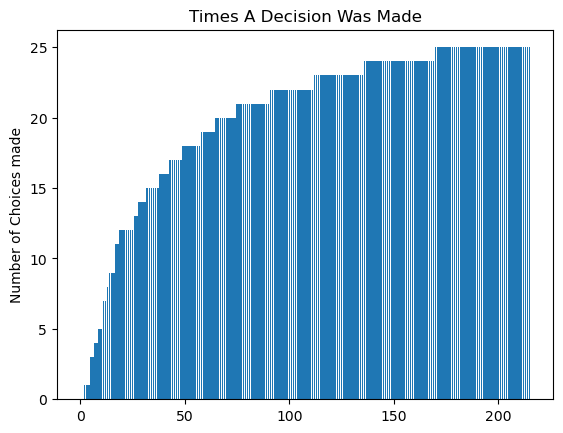

In [34]:
y =  np.sort(list(df["num_answered"]))
x = np.arange(0, len(y))

plt.bar(x, y)
plt.title("Times A Decision Was Made")
plt.ylabel("Number of Choices made")
plt.show()

In [35]:
all_agreements = {}
all_agreements_scores = []
for batch in range(1, max_batches): #six batches
    all_agreements.update(agreement(df, batch))
    
print(len(all_agreements))
print(all_agreements)
all_agreements_scores = np.array(list(all_agreements.values()))
all_agreements_percent = all_agreements_scores / 25 # 25 choices per task

print(all_agreements_scores)
print(all_agreements_percent)

np.mean(all_agreements_percent)

216
{'A1Y906Z67JI25Y': 10, 'ANN1IF9SWOGJ7': 15, 'A1C3IJCMZ66VD2': 15, 'AP14OXZ4QQ1O': 12, 'A1H2KFCXC57JTD': 12, 'A197703CQQGQB5': 16, 'AFVUJCJ9KQ33I': 13, 'A2P07TZW2RWY05': 13, 'A1RLMK2CKDYJ2G': 17, 'A1WKUNC2NQCX5J_SECOND': 22, 'ASVMU8OGKV3ID': 19, 'A3KLBK6128F8HC': 23, 'A3576EZYOZ5Y2T': 13, 'A3PKRJOKC5QYX6': 16, 'A38C0L7L37UM7F': 13, 'A20QWN0NW7IBB4': 13, 'A13VVMFPEPK1BZ': 2, 'A1I833MVGTY5PO': 16, 'A83UV73MNQ3KV': 8, 'A10O7L838QXNH3': 21, 'A36G32T2P87G8L': 18, 'A17CVKNSQMK98Z': 7, 'A7CN8LRR4I9NZ': 18, 'A3E13OVVI9MBCP': 12, 'A1ZVZ1JWUBUHFZ': 18, 'A3OUAR84WQO03Y': 20, 'A1RP328Y6PZ325': 17, 'A3KD5865HU0WM2': 12, 'ACHM2SO6R1SPZ': 17, 'A3EFKBV6W73WTX': 8, 'A1689LPUF6HS1A': 21, 'A1SCF3L6LTFQHF': 16, 'A2N5D3P3HPAOCI': 14, 'A3C5TMQP0L94K4': 19, 'A3O8JFBBMFKHWP': 8, 'A2B9VYT0VPEVLQ': 15, 'ATHOFOHCHTYIX': 12, 'A25IZ76G0Z0WXT': 9, 'A31UI2RCVXPSMN': 14, 'A2ZLQ2CWJ7C3CV': 7, 'A17K9X7OVHLU0U': 12, 'A17UAOC5ANZTLF': 19, 'AZ87W9Z8WTACR': 17, 'A265AKOTTNN0E1': 2, 'A2LJ1JPQNUTFGA': 21, 'A1BN0KDT37F15F'

0.5768518518518518

In [36]:
# add agreement to df
df.insert(column="agreement", loc=len(df.columns), value=None)

In [37]:
for worker in all_agreements.keys():
    df.loc[df["WorkerId"] == worker, "agreement"] = (all_agreements[worker] / 25)
df['agreement'] = df['agreement'].astype(float)

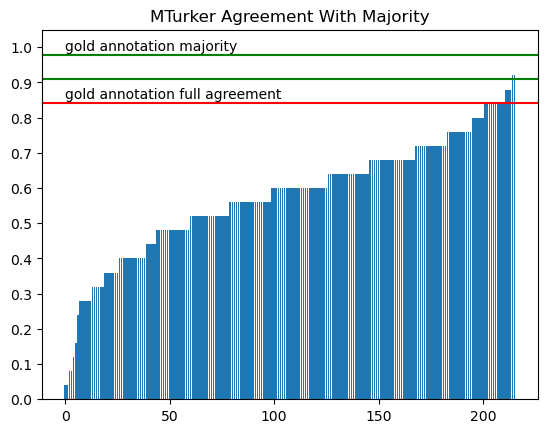

In [38]:
y =  np.sort(all_agreements_percent)
x = np.arange(0, len(y))

acc = gold_accuracy(df_gold, "Daniel")
plt.axhline(y=acc,color="r", ) # 10 minutes
plt.text(x=0, y=acc + (0.016 * acc), s="gold annotation full agreement")


acc1 = gold_accuracy(df_gold, "Kanishka", "majority")
plt.axhline(y=acc1,color="g",linestyle="-") # 10 minutes
plt.text(x=0, y=acc1 + (0.016 * acc), s="gold annotation majority")
acc2 = gold_accuracy(df_gold, "Will", "majority")
plt.axhline(y=acc2,color="g",linestyle="-") # 10 minutes

plt.axhline(y=1,color="white") # 10 minutes
# plt.text(x=0, y=1, s="gold annotation consensus")
plt.title("MTurker Agreement With Majority")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.bar(x, y)
plt.show()

In [39]:
print(overlap_contained)
print(len(overlap_contained["preference"]) + len(overlap_contained["temporal"]) + len(overlap_contained["instantiation"]))

{'preference': {1, 132, 133, 7, 12, 141, 142, 14, 21, 152, 27, 159, 32, 33, 166, 41, 170, 172, 47, 176, 181, 55, 58, 187, 63, 68, 74, 79, 86, 88, 97, 100, 106, 110, 111, 112, 121, 126}, 'temporal': {2, 132, 6, 139, 141, 15, 16, 145, 23, 155, 157, 30, 32, 33, 161, 41, 43, 171, 173, 52, 183, 184, 57, 65, 193, 66, 194, 73, 77, 206, 207, 82, 85, 218, 94, 224, 101, 110, 112, 114, 123}, 'instantiation': {17, 22, 6, 33}}
83


In [40]:
# get_q_answers(df, "temporal", 193)

In [41]:
print(cut_bottom(df, "agreement", 00)["agreement"].mean())
print(cut_bottom(df, "agreement", 10)["agreement"].mean())
print(cut_bottom(df, "agreement", 20)["agreement"].mean())
print(cut_bottom(df, "agreement", 30)["agreement"].mean())
print(cut_bottom(df, "agreement", 40)["agreement"].mean())

0.5768518518518518
0.6142268041237113
0.6413953488372092
0.6625165562913907
0.6843410852713179


In [42]:
print(cut_bottom(df, "WorkTimeInSeconds", 00)["WorkTimeInSeconds"].mean())
print(cut_bottom(df, "WorkTimeInSeconds", 10)["WorkTimeInSeconds"].mean())
print(cut_bottom(df, "WorkTimeInSeconds", 20)["WorkTimeInSeconds"].mean())
print(cut_bottom(df, "WorkTimeInSeconds", 30)["WorkTimeInSeconds"].mean())
print(cut_bottom(df, "WorkTimeInSeconds", 40)["WorkTimeInSeconds"].mean())


468.7638888888889
501.9896907216495
531.1104651162791
556.8609271523179
584.7519379844962


## Percent To Cut

In [43]:
drop_percent = 20

In [44]:
fastest = set(find_bottom(df, "WorkTimeInSeconds", "WorkerId", drop_percent))
disagreers = set(find_bottom(df, "agreement", "WorkerId", drop_percent))
indecisives = set(find_bottom(df, "num_answered", "WorkerId", drop_percent))

# print(fastest)
# print(disagreers)
# print(indecisives)

bottom_in_everything_set = fastest.union(indecisives).union(disagreers)
# remove That One Guy
# bottom_in_everything_set.add("AFWQB4527V3F2")
# remove That One Guy

print(bottom_in_everything_set)
print(len(bottom_in_everything_set))
print(len(df["WorkerId"]))

{'A1T9HLU7VFVE3Z', 'AP14OXZ4QQ1O', 'A294C3NQHIOI8K', 'A2L5JP4JENR64H', 'A32EHQA9ML98KM', 'AWO5FA4JLZRR0', 'A2ZLQ2CWJ7C3CV', 'A2OPL87BGLUU61', 'A3O8JFBBMFKHWP_SECOND', 'A175G7MRCGU2C1', 'A20ZFQ93DF0WA', 'A2C5HSMKN7QDM8', 'A197703CQQGQB5', 'A15RH1RKI8252F', 'A3RAKRCSCK21MV', 'A3EFKBV6W73WTX', 'APEJX2DGX4TYC', 'A6R6M6KVKTKZT', 'ABNTQ9OXGOJP0', 'AJ43BECTIUSGT', 'A3QMIV19OI5589_SECOND', 'AAIE54TN1UOKI', 'A3OUAR84WQO03Y', 'A2OGRT8VRQ42S5', 'A1PUIM6U5XPOGI', 'A17CVKNSQMK98Z', 'A265AKOTTNN0E1', 'A13VVMFPEPK1BZ', 'A3CRUF9Q168RA3', 'A2U4DQEDXF21LE', 'A2MALULLEZEZT0', 'A1T8VILAKHKGR1', 'A3ODCEDW955XXD', 'A2N5D3P3HPAOCI', 'A36HN50WA7RGAZ', 'A3C5TMQP0L94K4', 'ATHOFOHCHTYIX', 'A3SIBULMMRHMWU', 'A1H600PGSQDHAO', 'AFVUJCJ9KQ33I', 'A2V6FC84A78FS1', 'A1DPCRSK92UOT8', 'A259M5TIXUF7TN', 'A1ZDHA0TIBYYMF', 'A2CB9D65R9CY9A', 'AGLY8ZUKMZODY', 'A3PKRJOKC5QYX6_SECOND', 'A3BMYOEY1UU8VH', 'A3KD5865HU0WM2', 'A3T9YG3BOA0OV9', 'A5KMSTMQ55TGK', 'A3VXZVADINLMYZ', 'AFWQB4527V3F2', 'A12AC5NTW3OLM4', 'A1XSBLCCC1OWQ1', 'A

In [45]:
# cut_agreements(fastest, all_agreements, True)

In [46]:
print(len(bottom_in_everything_set))
print(len(worker_ids) - len(bottom_in_everything_set))
bottom_in_everything = cut_agreements(bottom_in_everything_set, all_agreements, True).values()
print(bottom_in_everything)

85
131
dict_values([0.6, 0.6, 0.52, 0.68, 0.88, 0.76, 0.92, 0.52, 0.64, 0.52, 0.52, 0.64, 0.84, 0.72, 0.72, 0.48, 0.72, 0.68, 0.68, 0.84, 0.64, 0.6, 0.56, 0.48, 0.76, 0.68, 0.84, 0.6, 0.52, 0.52, 0.56, 0.64, 0.48, 0.64, 0.76, 0.84, 0.56, 0.56, 0.56, 0.64, 0.64, 0.72, 0.6, 0.84, 0.56, 0.64, 0.64, 0.64, 0.76, 0.48, 0.92, 0.84, 0.6, 0.6, 0.68, 0.56, 0.56, 0.68, 0.52, 0.76, 0.68, 0.64, 0.64, 0.68, 0.6, 0.8, 0.6, 0.52, 0.6, 0.76, 0.64, 0.84, 0.68, 0.64, 0.72, 0.68, 0.6, 0.88, 0.68, 0.6, 0.52, 0.64, 0.6, 0.68, 0.72, 0.6, 0.68, 0.6, 0.52, 0.88, 0.6, 0.6, 0.76, 0.6, 0.6, 0.48, 0.56, 0.8, 0.48, 0.68, 0.84, 0.52, 0.56, 0.6, 0.72, 0.76, 0.64, 0.68, 0.76, 0.68, 0.52, 0.64, 0.52, 0.72, 0.64, 0.84, 0.76, 0.8, 0.56, 0.56, 0.68, 0.68, 0.64, 0.6, 0.6, 0.56, 0.72, 0.56, 0.6, 0.72, 0.72])


In [47]:
# get_q_consensus_without(df, "preference", 147, bottom_in_everything_set)

In [48]:
agreement_without_bottom(df, 3, bottom_in_everything_set)

{'ACHM2SO6R1SPZ': 16,
 'A1689LPUF6HS1A': 20,
 'A1SCF3L6LTFQHF': 14,
 'A2B9VYT0VPEVLQ': 15,
 'A31UI2RCVXPSMN': 13,
 'A17K9X7OVHLU0U': 10,
 'A17UAOC5ANZTLF': 18,
 'AZ87W9Z8WTACR': 15,
 'A2LJ1JPQNUTFGA': 18}

In [49]:
agreement_without_bottom(df, 1, bottom_in_everything_set)

{'ANN1IF9SWOGJ7': 17,
 'A1C3IJCMZ66VD2': 14,
 'A2P07TZW2RWY05': 12,
 'A1RLMK2CKDYJ2G': 14,
 'A1WKUNC2NQCX5J_SECOND': 20,
 'ASVMU8OGKV3ID': 20,
 'A3KLBK6128F8HC': 19,
 'A3576EZYOZ5Y2T': 15,
 'A3PKRJOKC5QYX6': 14,
 'A38C0L7L37UM7F': 9,
 'A20QWN0NW7IBB4': 12,
 'A1I833MVGTY5PO': 12}

In [50]:
# Get number of people still in each batch
for batch in range(1,max_batches): #six batches
    agreement = agreement_without_bottom(df, batch, bottom_in_everything_set)
    redo = ""
    if len(agreement) < 5:
        redo = "❎"
    print("Number:", batch, "\tRemaining Workers:", len(agreement), "\t", redo)

Number: 1 	Remaining Workers: 12 	 
Number: 2 	Remaining Workers: 6 	 
Number: 3 	Remaining Workers: 9 	 
Number: 4 	Remaining Workers: 7 	 
Number: 5 	Remaining Workers: 5 	 
Number: 6 	Remaining Workers: 5 	 
Number: 7 	Remaining Workers: 8 	 
Number: 8 	Remaining Workers: 8 	 
Number: 9 	Remaining Workers: 8 	 
Number: 10 	Remaining Workers: 7 	 
Number: 11 	Remaining Workers: 6 	 
Number: 12 	Remaining Workers: 8 	 
Number: 13 	Remaining Workers: 12 	 
Number: 14 	Remaining Workers: 6 	 
Number: 15 	Remaining Workers: 7 	 
Number: 16 	Remaining Workers: 10 	 
Number: 17 	Remaining Workers: 6 	 
Number: 18 	Remaining Workers: 6 	 
Number: 19 	Remaining Workers: 7 	 
Number: 20 	Remaining Workers: 9 	 
Number: 21 	Remaining Workers: 7 	 
Number: 22 	Remaining Workers: 8 	 
Number: 23 	Remaining Workers: 8 	 
Number: 24 	Remaining Workers: 10 	 


In [58]:
list(get_answers(get_batch(df, 4)).columns)
# get_answers(get_batch(df, 0))
# get_batch_questions(get_batch(df, 16))

['WorkerId',
 'Answer.101_1_temporal_blicketbash_even though_gekxtravaganza_blicketbash occured after gekxtravaganza._after',
 'Answer.101_1_temporal_blicketbash_even though_gekxtravaganza_gekxtravaganza occured after blicketbash._after',
 'Answer.103_3_preference_daxes_however_feps_daxes are blue flowers._love',
 'Answer.103_3_preference_daxes_however_feps_feps are blue flowers._love',
 'Answer.106_6_preference_Wugsville_however_Gektopia_Gektopia has snowy winters._hate',
 'Answer.106_6_preference_Wugsville_however_Gektopia_Wugsville has snowy winters._hate',
 'Answer.10_10_instantiation_blickets_for example_geks_blickets are instances of geks._are',
 'Answer.10_10_instantiation_blickets_for example_geks_geks are instances of blickets._are',
 'Answer.10_10_preference_Fepopolis_although_Gektopia_Fepopolis has skyscrapers._love',
 'Answer.10_10_preference_Fepopolis_although_Gektopia_Gektopia has skyscrapers._love',
 'Answer.121_1_temporal_daxday_hence_gekxtravaganza_daxday occured after

In [52]:
all_agreements = {}
all_agreements_scores = []
for batch in range(1,max_batches): #six batches
    all_agreements.update(agreement_without_bottom(df, batch, bottom_in_everything_set))


print(len(bottom_in_everything_set))
print(len(all_agreements))
print(all_agreements)
all_agreements_scores = np.array(list(all_agreements.values()))
all_agreements_percent = all_agreements_scores / 25 # 25 choices per task

print(all_agreements_scores)
print(all_agreements_percent)

np.mean(all_agreements_percent)


85
131
{'ANN1IF9SWOGJ7': 17, 'A1C3IJCMZ66VD2': 14, 'A2P07TZW2RWY05': 12, 'A1RLMK2CKDYJ2G': 14, 'A1WKUNC2NQCX5J_SECOND': 20, 'ASVMU8OGKV3ID': 20, 'A3KLBK6128F8HC': 19, 'A3576EZYOZ5Y2T': 15, 'A3PKRJOKC5QYX6': 14, 'A38C0L7L37UM7F': 9, 'A20QWN0NW7IBB4': 12, 'A1I833MVGTY5PO': 12, 'A10O7L838QXNH3': 19, 'A36G32T2P87G8L': 20, 'A7CN8LRR4I9NZ': 20, 'A3E13OVVI9MBCP': 14, 'A1ZVZ1JWUBUHFZ': 18, 'A1RP328Y6PZ325': 19, 'ACHM2SO6R1SPZ': 16, 'A1689LPUF6HS1A': 20, 'A1SCF3L6LTFQHF': 14, 'A2B9VYT0VPEVLQ': 15, 'A31UI2RCVXPSMN': 13, 'A17K9X7OVHLU0U': 10, 'A17UAOC5ANZTLF': 18, 'AZ87W9Z8WTACR': 15, 'A2LJ1JPQNUTFGA': 18, 'A1BN0KDT37F15F': 13, 'ACHM2SO6R1SPZ_SECOND': 19, 'A110WAS3D3UGCL': 15, 'A1WKUNC2NQCX5J': 20, 'A2FK6782M09EBO': 22, 'A107V0POF1ZCWL': 12, 'AROYFQ1PG1III': 18, 'A2EK1HDV4I4GSK': 20, 'A3PN17H3QT51O': 22, 'A3CC5MOD5YKYRG': 17, 'A1CQTF1B9G5U8K': 16, 'A1X57FIBR8OOBG': 13, 'A3UB7R90PEEP76': 15, 'AVL74KCJXJNR6': 18, 'A21HKZOP94F9MD': 17, 'A3QTO07BNMNJ8O': 14, 'A1KJ9O5JU7532S': 20, 'A1HQGU5SA9UORE': 14

0.6766412213740457

In [53]:
arr = np.array(all_agreements_percent)
filter = arr > .5
print(len(arr))
print(len(arr[filter]))
print(len(arr) - len(arr[filter]))


131
122
9


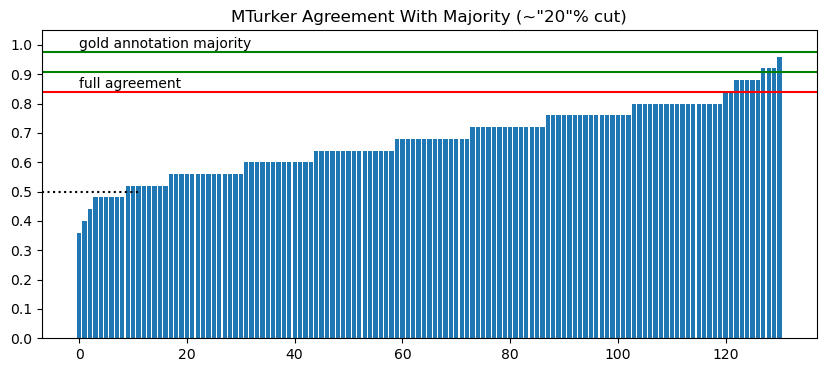

In [56]:
y =  np.sort(all_agreements_percent)
x = np.arange(0, len(y))

acc = gold_accuracy(df_gold, "Daniel")
plt.axhline(y=acc,color="r", ) # 10 minutes
plt.text(x=0, y=acc + (0.016 * acc), s="full agreement")


acc1 = gold_accuracy(df_gold, "Kanishka", "majority")
plt.axhline(y=acc1,color="g",linestyle="-") # 10 minutes
plt.text(x=0, y=acc1 + (0.016 * acc), s="gold annotation majority")
acc2 = gold_accuracy(df_gold, "Will", "majority")
plt.axhline(y=acc2,color="g",linestyle="-") # 10 minutes

# plt.axhline(y=.5,color="b",linestyle="dashed") # 10 minutes


plt.axhline(y=1,color="white") # 10 minutes
plt.axhline(y=.5,color="black", linestyle="dotted", xmin=0, xmax=.125) 
# plt.text(x=0, y=1, s="gold annotation consensus")
plt.title("MTurker Agreement With Majority (~\"" + str(drop_percent) + "\"% cut)")
plt.yticks(np.arange(0, 1.1, 0.1))
plt.bar(x, y)
plt.rcParams["figure.figsize"] = (10,4)
plt.show()

In [55]:
# plt.hist( y)


# First Pass

## CUT GRAPHS

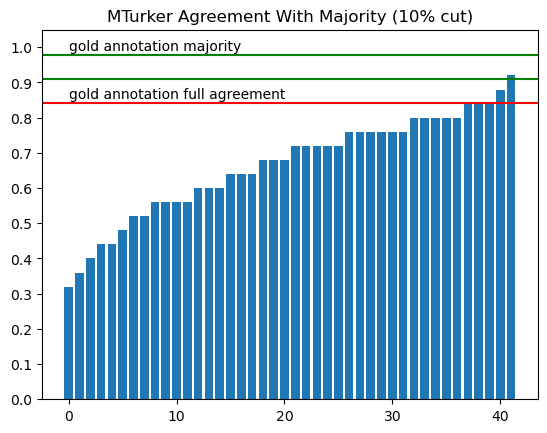 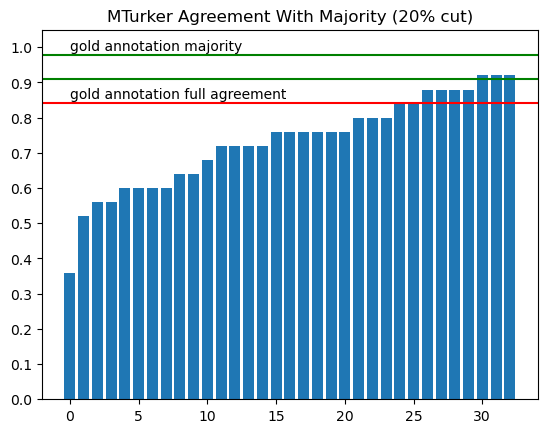 

| percent | people cut |
|---|----|
| 10% | 12 |
| 20% | 21 |
| 30% | 32 |
| 40% | 37 |

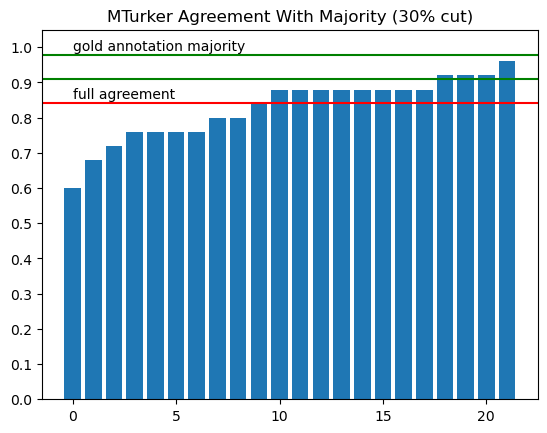 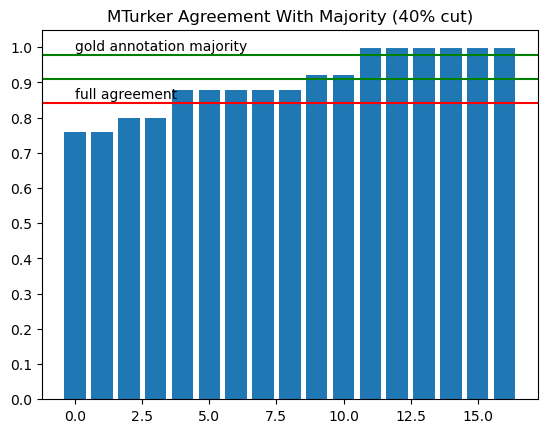